# medical charges

QUESTION: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

##### Downloading the data

In [3]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [4]:
from urllib.request import urlretrieve
urlretrieve(url, "data/medical.csv")

('data/medical.csv', <http.client.HTTPMessage at 0x1c76a606490>)

In [5]:
import pandas as pd
df = pd.read_csv("data/medical.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


##### Data Visualization

In [8]:
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
%matplotlib inline

In [9]:
sns.set_style("dark")
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.figsize"] = (10,6)
matplotlib.rcParams["figure.facecolor"] = "#00000000"

##### AGE

In [10]:
fig = px.histogram(df, x = "age",marginal="box", nbins = 47, title="distribution of age")
fig.update_layout(bargap = 0.1)
fig.show()

##### BODY MASS INDEX

In [11]:
fig = px.histogram(df, x = "age",marginal="box", color_discrete_sequence=["red"], title="Distribution of BMI (Body Mass Index)")
fig.update_layout(bargap = 0.1)
fig.show()

In [12]:
fig = px.histogram(df, x = "charges",marginal="box", color_discrete_sequence=["red","grey"], color="smoker",title="Annual Medical Charges")
fig.update_layout(bargap = 0.1)
fig.show()

##### Smokers and non Smokers

In [13]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [14]:
px.histogram(df,x = "smoker",color='sex', title = "Smokers")

##### Age vs Charges

In [15]:
fig = px.scatter(df, x= "age", y ="charges",color="smoker", opacity = 0.5, title="Age vs Charges")
fig.update_traces(marker_size = 5)
fig.show()

##### BMI charges

In [16]:
fig = px.scatter(df, x= "bmi", y ="charges", color="smoker", opacity = 0.5, title="BMI vs Charges")
fig.update_traces(marker_size = 5)
fig.show()

##### corelation heatmap


Text(0.5, 1.0, 'Correlation heatmap')

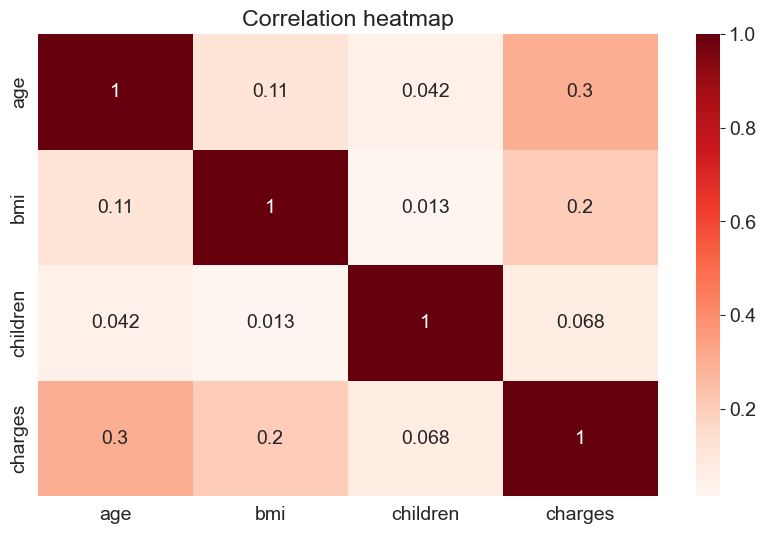

In [17]:
sns.heatmap(df.select_dtypes(include='number').corr(), cmap = "Reds", annot=True)
plt.title("Correlation heatmap")

##### Linear Regression using a Single Feature


In [34]:
non_somker_df = df[df['smoker'] == "no"]
non_somker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


Next, let's visualize the relationship between "age" and "charges"



In [35]:
fig = px.scatter(non_somker_df, x = "age", y = "charges", title= "Age vs Charges Distribution")
fig.show()

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

y=wx+b

The line is characterized two numbers: 
w (called "slope") and 
b (called "intercept").

##### Model

In [36]:
def estimate_charges(age,w,c):
    return w*age + c

In [59]:
w = 50
c = 100
age = non_somker_df.age
estimate = estimate_charges(age,w,c)

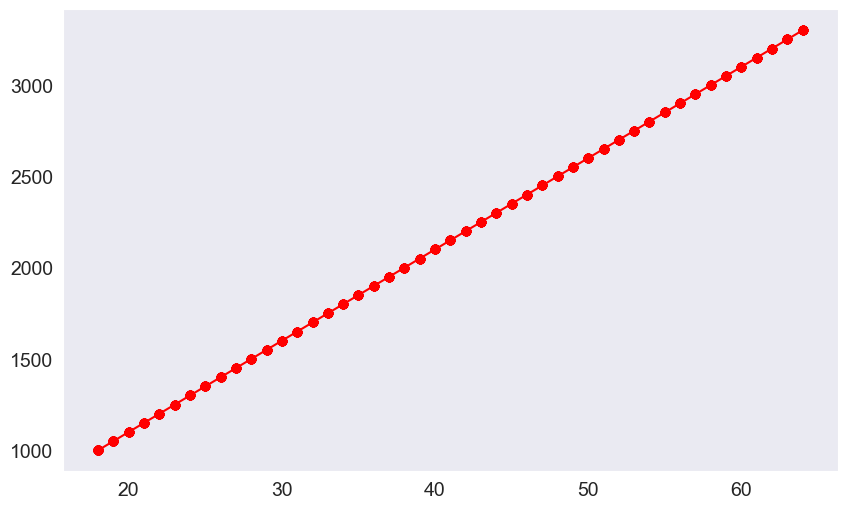

In [61]:
plt.plot(non_somker_df["age"],estimate, "r-o")

In [62]:
fig = px.scatter(non_somker_df, x = "age", y = "charges", title= "Age vs Charges Distribution")
fig.show()

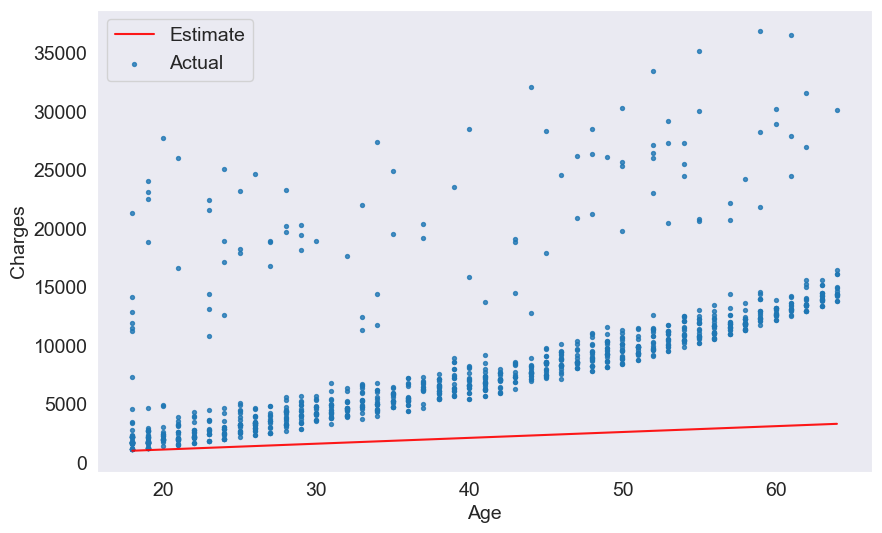

In [ ]:
target = non_somker_df.charges

plt.plot(age, estimate, 'r', alpha=0.9)
plt.scatter(age, target, s=8,alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])


In [64]:
def add_parameters(w, b):
    target = non_somker_df.charges
    age = non_somker_df.age
    estimate = estimate_charges(age,w,b)
    plt.plot(age, estimate, 'r', alpha=0.9)
    plt.scatter(age, target, s=8,alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])



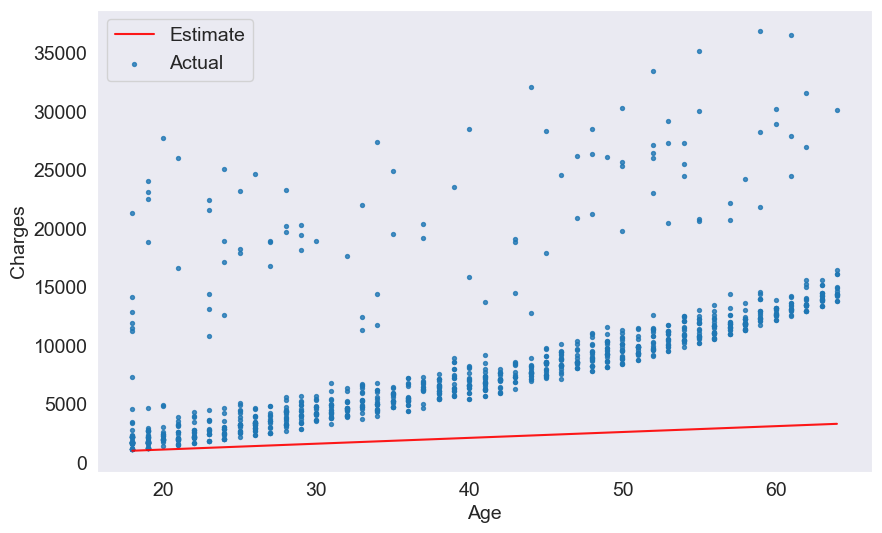

In [65]:
add_parameters(50,100)

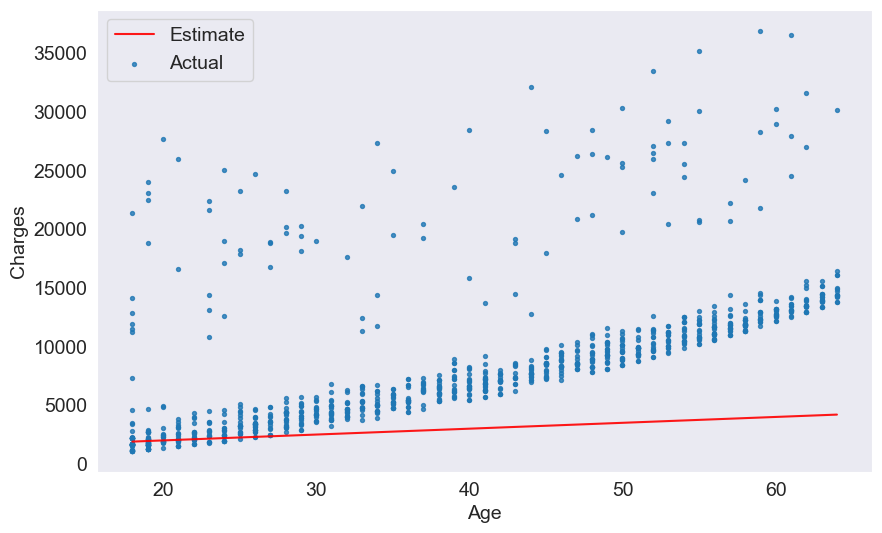

In [66]:
add_parameters(50,1000)

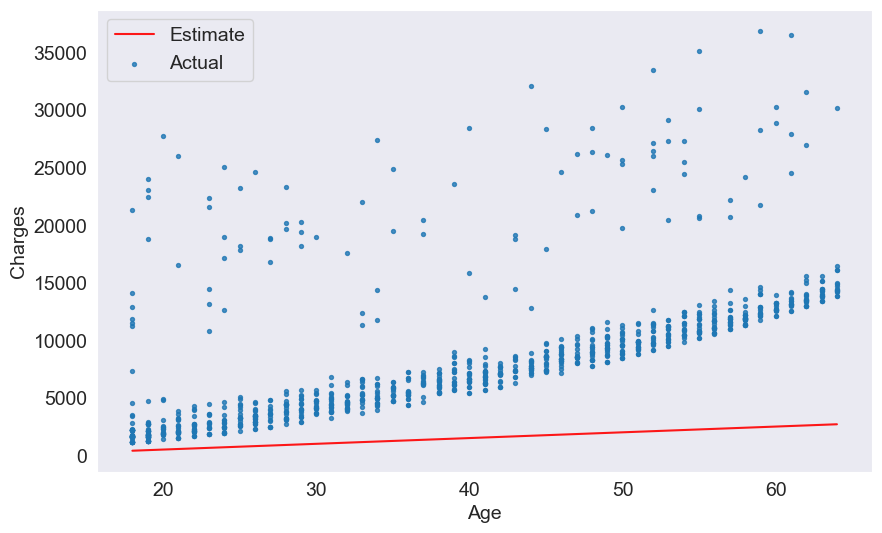

In [67]:
add_parameters(50,-500)

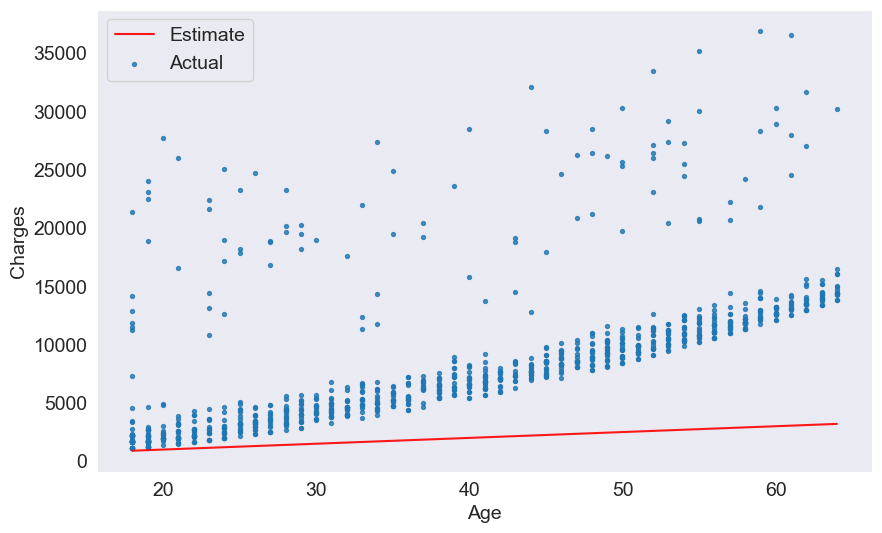

In [68]:
add_parameters(50, 0)

##### Loss/Cost Function


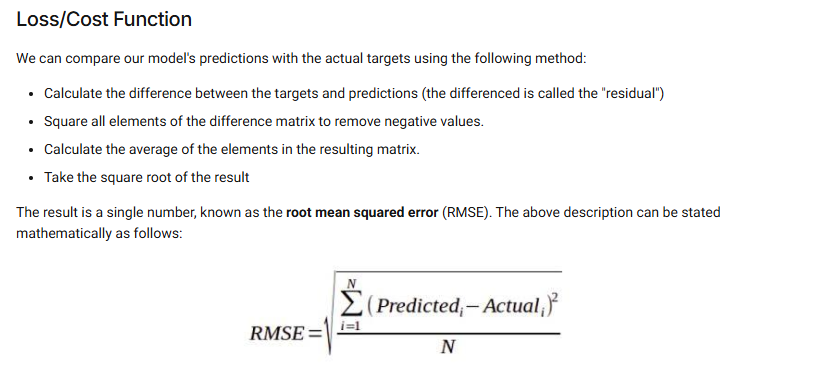

In [71]:
import numpy as np

In [72]:
def rmse(predicted, actual):
    return np.sqrt(np.mean(np.square(predicted - actual)))

In [ ]:
estimate

1       1000
1317    1000
1334    1000
22      1000
571     1000
        ... 
534     3300
752     3300
635     3300
62      3300
603     3300
Name: age, Length: 1064, dtype: int64

In [75]:
non_somker_df.charges

1        1725.55230
1317     1163.46270
1334     2205.98080
22       1137.01100
571      2219.44510
           ...     
534     13831.11520
752     14210.53595
635     14410.93210
62      30166.61817
603     16085.12750
Name: charges, Length: 1064, dtype: float64

In [76]:
rmse(estimate, non_somker_df.charges)

np.float64(8461.949562575492)

modifying try parameters functions

In [78]:
def add_parameters(w, b):
    target = non_somker_df.charges
    age = non_somker_df.age
    estimate = estimate_charges(age,w,b)
    plt.plot(age, estimate, 'r', alpha=0.9)
    plt.scatter(age, target, s=8,alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    print(f"RMSE Loss: {rmse(estimate, non_somker_df.charges)}")

RMSE Loss: 8461.949562575492


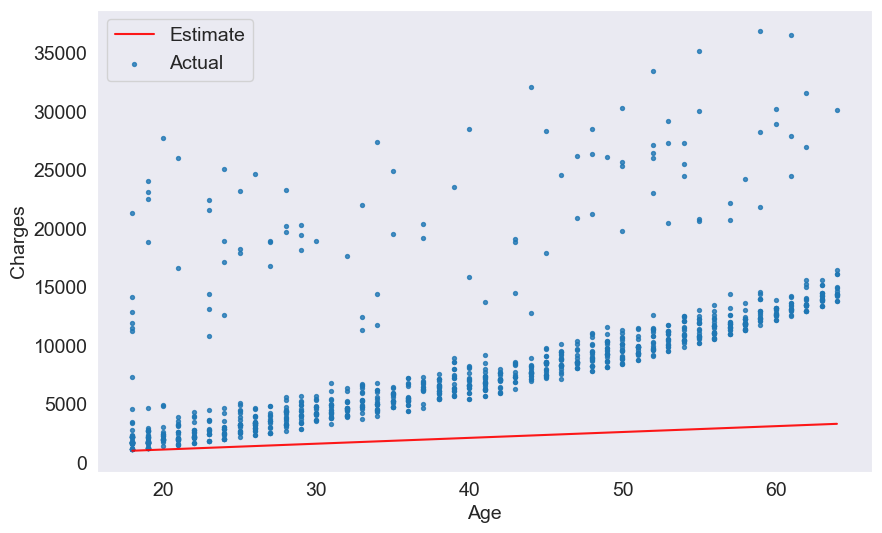

In [79]:
add_parameters(50,100)

### Linear Regression using sciket learn


In [ ]:
import sklearn

ModuleNotFoundError: No module named 'sklearn'